In [ ]:
# import pandas as pd
# campaign = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')

# import polars as pl
# campaign = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv', schema_overrides={'nr.employed': pl.Float64})

In [9]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

# -----------------------------
# Load training data
# -----------------------------
train_url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv"

df = pd.read_csv(train_url)

# -----------------------------
# Separate features and target
# -----------------------------
X = df.drop("y", axis=1)
y = df["y"]

# Convert target to binary
y = y.map({"yes": 1, "no": 0})

# -----------------------------
# Split data
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# -----------------------------
# Identify categorical columns
# -----------------------------
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# -----------------------------
# Preprocessing
# -----------------------------
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numeric_transformer, numeric_cols)
    ]
)

# -----------------------------
# Build model pipeline
# -----------------------------
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

# -----------------------------
# Train model
# -----------------------------
model.fit(X_train, y_train)

# -----------------------------
# Evaluate model
# -----------------------------
preds = model.predict(X_test)

accuracy = accuracy_score(y_test, preds)

print("Model Accuracy:", accuracy)

# -----------------------------
# Save trained model
# -----------------------------
joblib.dump(model, "bank_marketing_model.pkl")

print("Model saved successfully.")

# -----------------------------
# Load holdout dataset
# -----------------------------
holdout_url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test.csv"

holdout = pd.read_csv(holdout_url)

# -----------------------------
# Make predictions
# -----------------------------
holdout_predictions = model.predict(holdout)

# -----------------------------
# Create submission dataframe
# -----------------------------
submission = pd.DataFrame({
    "predictions": holdout_predictions
})

# Verify row count
print(submission.shape)

# -----------------------------
# Save predictions to CSV
file_name = "bank_predictions.csv"

submission.to_csv(file_name, index=False)

# Print confirmation and filename
print("Prediction file created successfully.")
print("Prediction file name:", file_name)

Model Accuracy: 0.8888589155651471
Model saved successfully.
(4119, 1)
Prediction file created successfully.
Prediction file name: bank_predictions.csv


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv(
    'https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv'
)

# Convert target column to numeric
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# List of demographic columns to analyze
demographics = [
    'job',
    'marital',
    'education',
    'housing',
    'loan',
    'contact',
    'day_of_week',
    'month'
]

# Loop through each demographic
for col in demographics:

    # Calculate subscription rates
    subscription_rates = df.groupby(col)['y'].mean()

    # Find highest group
    best_group = subscription_rates.idxmax()
    best_rate = subscription_rates.max()

    # Print results
    print(f"\nDemographic Category: {col}")
    print(f"Most likely to subscribe: {best_group}")
    print(f"Subscription rate: {round(best_rate * 100, 2)}%")


Demographic Category: job
Most likely to subscribe: student
Subscription rate: 31.4%

Demographic Category: marital
Most likely to subscribe: single
Subscription rate: 14.07%

Demographic Category: education
Most likely to subscribe: illiterate
Subscription rate: 25.0%

Demographic Category: housing
Most likely to subscribe: yes
Subscription rate: 11.68%

Demographic Category: loan
Most likely to subscribe: no
Subscription rate: 11.44%

Demographic Category: contact
Most likely to subscribe: cellular
Subscription rate: 14.87%

Demographic Category: day_of_week
Most likely to subscribe: thu
Subscription rate: 12.37%

Demographic Category: month
Most likely to subscribe: mar
Subscription rate: 50.81%


In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv(
    'https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv'
)

# Convert target to numeric
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Select factors to analyze
factors = [
    'job',
    'marital',
    'education',
    'housing',
    'loan',
    'contact',
    'day_of_week',
    'month'
]

# Group by all selected factors
grouped = (
    df.groupby(factors)['y']
    .agg(['mean', 'count'])
    .reset_index()
)

# Optional:
# Remove tiny sample sizes so results are more reliable
grouped = grouped[grouped['count'] >= 20]

# Find highest subscription rate
best_row = grouped.loc[grouped['mean'].idxmax()]

# Print results
print("Most likely customer profile to subscribe:\n")

for factor in factors:
    print(f"{factor}: {best_row[factor]}")

print(f"\nSubscription Rate: {round(best_row['mean'] * 100, 2)}%")
print(f"Number of customers with this profile: {best_row['count']}")

Most likely customer profile to subscribe:

job: admin.
marital: single
education: university.degree
housing: yes
loan: no
contact: cellular
day_of_week: thu
month: apr

Subscription Rate: 50.0%
Number of customers with this profile: 28


In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv(
    'https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv'
)

# Convert target column to numeric
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# -------------------------------------------------
# Create High vs Low Consumer Confidence groups
# -------------------------------------------------

# Use the median consumer confidence index as threshold
median_conf = df['cons.conf.idx'].median()

df['confidence_level'] = df['cons.conf.idx'].apply(
    lambda x: 'High Confidence' if x >= median_conf else 'Low Confidence'
)

# -------------------------------------------------
# Calculate subscription rates
# -------------------------------------------------

results = (
    df.groupby('confidence_level')['y']
    .agg(['mean', 'count'])
    .reset_index()
)

# -------------------------------------------------
# Print results
# -------------------------------------------------

print("Consumer Confidence Impact on Subscription Rates\n")

for _, row in results.iterrows():

    print(f"Confidence Level: {row['confidence_level']}")
    print(f"Subscription Rate: {round(row['mean'] * 100, 2)}%")
    print(f"Number of Customers: {row['count']}")
    print()

# -------------------------------------------------
# Compare difference directly
# -------------------------------------------------

high_rate = results.loc[
    results['confidence_level'] == 'High Confidence',
    'mean'
].values[0]

low_rate = results.loc[
    results['confidence_level'] == 'Low Confidence',
    'mean'
].values[0]

difference = (high_rate - low_rate) * 100

print("--------------------------------------")

if difference > 0:
    print(f"High consumer confidence increases subscription rates by {round(difference,2)}%")
else:
    print(f"Low consumer confidence increases subscription rates by {round(abs(difference),2)}%")

Consumer Confidence Impact on Subscription Rates

Confidence Level: High Confidence
Subscription Rate: 12.73%
Number of Customers: 19866

Confidence Level: Low Confidence
Subscription Rate: 9.76%
Number of Customers: 17203

--------------------------------------
High consumer confidence increases subscription rates by 2.97%


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Load data
df = pd.read_csv(
    'https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv'
)

# Convert target
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Features and target
X = df.drop('y', axis=1)
y = df['y']

# Identify categorical/numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('cat',
     OneHotEncoder(handle_unknown='ignore'),
     categorical_cols),

    ('num',
     SimpleImputer(strategy='median'),
     numeric_cols)
])

# Build pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ))
])

# Train model
model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

In [15]:
from sklearn.tree import export_text

# Get trained tree
tree = model.named_steps['classifier']

# Get feature names after encoding
feature_names = (
    model.named_steps['preprocessor']
    .get_feature_names_out()
)

# Print tree rules
tree_rules = export_text(
    tree,
    feature_names=list(feature_names)
)

print(tree_rules)

|--- num__nr.employed <= 5087.65
|   |--- num__pdays <= 16.50
|   |   |--- num__nr.employed <= 5049.85
|   |   |   |--- cat__day_of_week_mon <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- cat__day_of_week_mon >  0.50
|   |   |   |   |--- class: 1
|   |   |--- num__nr.employed >  5049.85
|   |   |   |--- num__age <= 21.50
|   |   |   |   |--- class: 0
|   |   |   |--- num__age >  21.50
|   |   |   |   |--- class: 1
|   |--- num__pdays >  16.50
|   |   |--- cat__contact_telephone <= 0.50
|   |   |   |--- num__cons.price.idx <= 93.17
|   |   |   |   |--- class: 0
|   |   |   |--- num__cons.price.idx >  93.17
|   |   |   |   |--- class: 0
|   |   |--- cat__contact_telephone >  0.50
|   |   |   |--- cat__month_apr <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__month_apr >  0.50
|   |   |   |   |--- class: 1
|--- num__nr.employed >  5087.65
|   |--- num__cons.conf.idx <= -46.65
|   |   |--- num__euribor3m <= 1.37
|   |   |   |--- num__pdays <= 6.50
|   |   |   |   |--- c

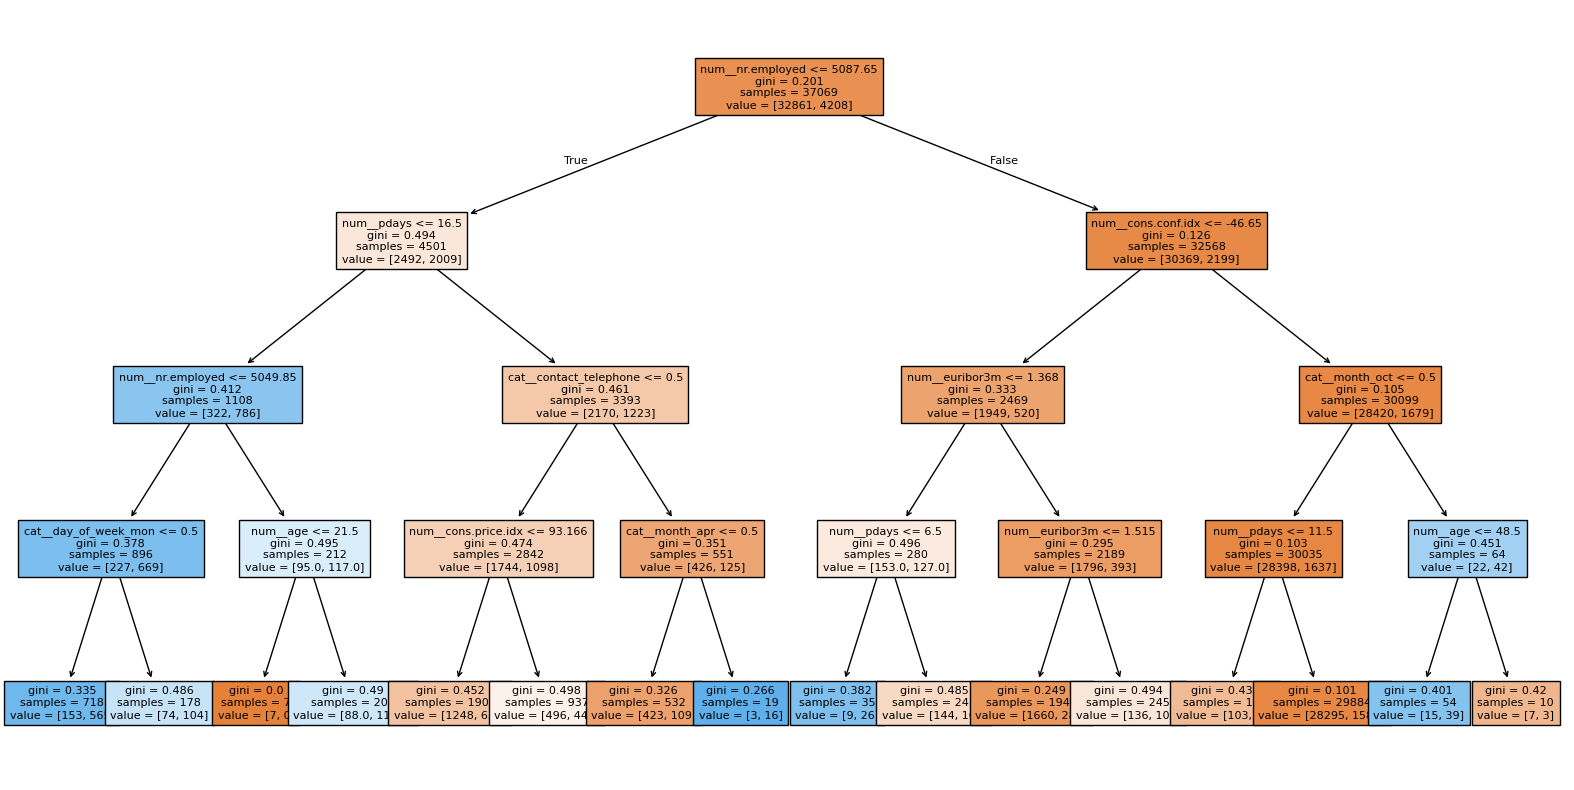

In [17]:
from sklearn import tree
import matplotlib.pyplot as plt

# Get classifier separately
decision_tree = model.named_steps['classifier']

plt.figure(figsize=(20,10))

tree.plot_tree(
    decision_tree,
    feature_names=feature_names,
    filled=True,
    fontsize=8
)

plt.show()